# Flight Delay Analysis

## Project Overview
For this project we'll analyze 2015 flight delay dataset from [kaggle](https://www.kaggle.com/datasets/usdot/flight-delays)

Flight delay severely impact airlines by causing a cascading "ripple effect" through,
creating operational chaos and significant financial losses.
This project analyzes flight delay patterns to understand:

- Which airlines experience the most delays
- Which airports generate the most delays
- What type of delays is the main issue
- When do delays occur most frequently 

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn 
- Tableau

### Key Questions
1. Which airlines have the highest delay rates?
2. Which airports experience the most delays?
3. What are the most common delay causes?
4. Are there seasonal patterns in delays?

## 1. Import Needed Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 2. Load Datasets

In [5]:
df_airports = pd.read_csv("airports.csv")
df_airlines = pd.read_csv("airlines.csv")
df_flights = pd.read_csv("flights.csv", low_memory=False)

## 3. Merge Datasets



In [6]:
# look at datasets to see where to join on
print(df_airports.head(2))
print(df_airlines.head(2))
print(df_flights.head(2))

  IATA_CODE                              AIRPORT       CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport  Allentown    PA     USA   
1       ABI             Abilene Regional Airport    Abilene    TX     USA   

   LATITUDE  LONGITUDE  
0  40.65236   -75.4404  
1  32.41132   -99.6819  
  IATA_CODE                 AIRLINE
0        UA   United Air Lines Inc.
1        AA  American Airlines Inc.
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY  \
0          -22.0         0          0             

In [7]:
# Merging data

# Merging flights with airline data using the airline code
df_merge = pd.merge(df_flights, df_airlines, left_on ='AIRLINE', right_on = 'IATA_CODE', how = "left")

# Merging new dataset above with airport data, 
# due to origin and destination airports have to add prefix to differentiate the two
df_merge = pd.merge(df_merge, df_airports.add_prefix("ORIGIN_"), left_on = 'ORIGIN_AIRPORT', right_on = "ORIGIN_IATA_CODE"
                    , how = "left")

# Merge with the destination airport
df_merge = pd.merge(df_merge, df_airports.add_prefix("DEST_"), left_on = "DESTINATION_AIRPORT", right_on = "DEST_IATA_CODE", how = "left")

In [8]:
# check columns of fully merge dataset
df_merge.columns



Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE_x', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT_x', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'IATA_CODE', 'AIRLINE_y',
       'ORIGIN_IATA_CODE', 'ORIGIN_AIRPORT_y', 'ORIGIN_CITY', 'ORIGIN_STATE',
       'ORIGIN_COUNTRY', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE',
       'DEST_IATA_CODE', 'DEST_AIRPORT', 'DEST_CITY', 'DEST_STATE',
       'DEST_COUNTRY', 'DEST_LATITUDE', 'DEST_LONGITUDE'],
      dtype='object')

In [9]:
# check dataset
df_merge.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT_x,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_IATA_CODE,DEST_AIRPORT,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,USA,61.17432,-149.99619,SEA,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,USA,33.94254,-118.40807,PBI,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,USA,37.61900,-122.37484,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,USA,33.94254,-118.40807,MIA,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,USA,47.44898,-122.30931,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


In [10]:
# Select columns needed for analysis
df =  df_merge[[
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE_y",
    "ORIGIN_AIRPORT_y",
    "DEST_AIRPORT",
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]].copy()

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_y,ORIGIN_AIRPORT_y,DEST_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Seattle-Tacoma International Airport,-11.0,-22.0,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Palm Beach International Airport,-8.0,-9.0,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US Airways Inc.,San Francisco International Airport,Charlotte Douglas International Airport,-2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Miami International Airport,-5.0,-9.0,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Ted Stevens Anchorage International Airport,-1.0,-21.0,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning


In [11]:
# check column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5819079 entries, 0 to 5819078
Data columns (total 14 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE_y            object 
 5   ORIGIN_AIRPORT_y     object 
 6   DEST_AIRPORT         object 
 7   DEPARTURE_DELAY      float64
 8   ARRIVAL_DELAY        float64
 9   AIR_SYSTEM_DELAY     float64
 10  SECURITY_DELAY       float64
 11  AIRLINE_DELAY        float64
 12  LATE_AIRCRAFT_DELAY  float64
 13  WEATHER_DELAY        float64
dtypes: float64(7), int64(4), object(3)
memory usage: 665.9+ MB


In [12]:
# select delay columns
delay_breakdown_cols = [
    'AIR_SYSTEM_DELAY',         # Air traffic interruptions
    'WEATHER_DELAY',            # Weather related delays
    'AIRLINE_DELAY',            # Airline related delay
    'SECURITY_DELAY',           # Security related delays  
    'LATE_AIRCRAFT_DELAY'       # Previous flight late
]

# Create delay indicator
df['IS_DELAYED'] = df['ARRIVAL_DELAY'] > 15 # Airplane arrival is deemed late if it arrive 15 mins or longer past original arrive time

# Sum of total Delay from all possible delay breakdown for flights
df['TOTAL_DELAY_BREAKDOWN'] = df[delay_breakdown_cols].fillna(0).sum(axis=1)

# Rename columns 
df = df.rename(columns={"AIRLINE_y": "AIRLINE_NAME", "ORIGIN_AIRPORT_y": "ORIGIN_AIRPORT"})
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED,TOTAL_DELAY_BREAKDOWN
0,2015,1,1,4,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Seattle-Tacoma International Airport,-11.0,-22.0,NaN,NaN,NaN,NaN,NaN,False,0.0
1,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Palm Beach International Airport,-8.0,-9.0,NaN,NaN,NaN,NaN,NaN,False,0.0
2,2015,1,1,4,US Airways Inc.,San Francisco International Airport,Charlotte Douglas International Airport,-2.0,5.0,NaN,NaN,NaN,NaN,NaN,False,0.0
3,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Miami International Airport,-5.0,-9.0,NaN,NaN,NaN,NaN,NaN,False,0.0
4,2015,1,1,4,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Ted Stevens Anchorage International Airport,-1.0,-21.0,NaN,NaN,NaN,NaN,NaN,False,0.0


In [76]:
# Understanding dataset
print(f"Length of dataset: {len(df)}")
print(f"Delayed flights: {df['IS_DELAYED'].sum():,} ({df['IS_DELAYED'].mean()*100:.1f}%)")
print(f"On-time flights: {(~df['IS_DELAYED']).sum():,} ({(~df['IS_DELAYED']).mean()*100:.1f}%)")

Length of dataset: 5819079
Delayed flights: 1,023,498 (17.6%)
On-time flights: 4,795,581 (82.4%)


<Axes: xlabel='TOTAL_DELAY_BREAKDOWN'>

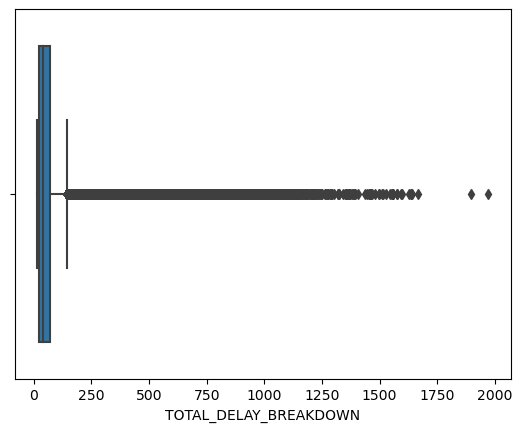

In [14]:
# Distribution of delay time in dataset

dist_df = df[df["IS_DELAYED"] == True]

sns.boxplot(data = dist_df, x = "TOTAL_DELAY_BREAKDOWN")

With delays in the dataset there are outliers that go from 250 to 2000 mins of delay

24.0 72.0


<Axes: xlabel='TOTAL_DELAY_BREAKDOWN'>

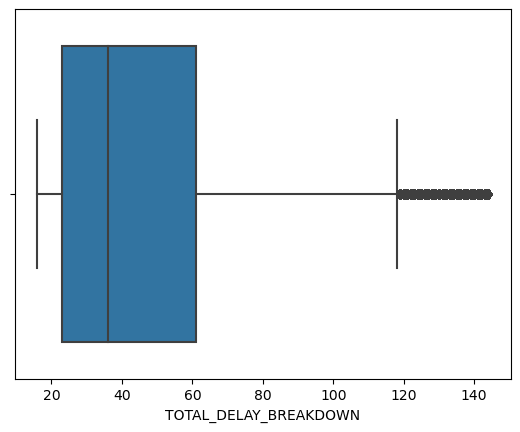

In [49]:
# Removing outlier flight delay with inter quartile range

# find q1 and q3
q1, q3 = np.percentile(dist_df["TOTAL_DELAY_BREAKDOWN"], [25,75])
print(q1,q3)

# create iqr
iqr = q3 - q1

# find the higher and lower bound
lower_bound = q1 - 1.5*iqr 
higher_bound= q3 + 1.5*iqr
iqr_range = [lower_bound, higher_bound]
iqr_range

# remove flights using lower and higher bound, but keeping flights 
# with no delays as well to not create a dataset with just delay flights
remove_outlier = df[
    (
        (df["TOTAL_DELAY_BREAKDOWN"] >= lower_bound) &
        (df["TOTAL_DELAY_BREAKDOWN"] <= higher_bound)
    ) | 
    (~df["IS_DELAYED"])
]

# create boxplot to show distribution after removing outliers
dist2 = remove_outlier[remove_outlier["IS_DELAYED"] == True]
sns.boxplot(data = dist2, x = "TOTAL_DELAY_BREAKDOWN")

 With the outliers remove we can cleary see the boxplot distribution now 

In [50]:
# taking a look at new dataset
remove_outlier.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED,TOTAL_DELAY_BREAKDOWN
0,2015,1,1,4,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Seattle-Tacoma International Airport,-11.0,-22.0,NaN,NaN,NaN,NaN,NaN,False,0.0
1,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Palm Beach International Airport,-8.0,-9.0,NaN,NaN,NaN,NaN,NaN,False,0.0
2,2015,1,1,4,US Airways Inc.,San Francisco International Airport,Charlotte Douglas International Airport,-2.0,5.0,NaN,NaN,NaN,NaN,NaN,False,0.0
3,2015,1,1,4,American Airlines Inc.,Los Angeles International Airport,Miami International Airport,-5.0,-9.0,NaN,NaN,NaN,NaN,NaN,False,0.0
4,2015,1,1,4,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Ted Stevens Anchorage International Airport,-1.0,-21.0,NaN,NaN,NaN,NaN,NaN,False,0.0


In [46]:
# changing dataset name for convenience 
df_final = remove_outlier.copy()

With removing the outlier flight delays that will help with better representation when visualizing delay, with the outliers it can sway airline, airport, to have long or short delays

In [77]:
# Delay count by Airport
print(df_final.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].count().sort_values().head(10))
print(df_final.groupby("DEST_AIRPORT")["IS_DELAYED"].count().sort_values().head(10))



ORIGIN_AIRPORT
Ithaca Tompkins Regional Airport                               33
King Salmon Airport                                            63
Gustavus Airport                                               74
Dillingham Airport                                             77
Barnstable Municipal Airport                                   78
St. Cloud Regional Airport                                     79
Wilmington Airport                                             91
Adak Airport                                                   96
Pago Pago International Airport (Tafuna Airport)              104
Northeast Florida Regional Airport (St. Augustine Airport)    150
Name: IS_DELAYED, dtype: int64
DEST_AIRPORT
Ithaca Tompkins Regional Airport                               35
King Salmon Airport                                            63
Gustavus Airport                                               76
Dillingham Airport                                             77
St. Cloud Regiona

With the delay count by airport we can see that there are some airports that have less than 100 delays total. Those airports  can produce unstable delay rates, which do not accurately reflect typical airport performance. 

In [102]:
# Get airports with over 1000 delays
depart_delay = df_final.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].count().sort_values(ascending = False)
airport_depart_1000 = depart_delay[depart_delay > 1000].index.tolist()

depart_delay_airports =df_final[df_final["ORIGIN_AIRPORT"].isin(airport_depart_1000)]

# Get airports with over 1000 delays
dest_delay = df_final.groupby("DEST_AIRPORT")["IS_DELAYED"].count().sort_values(ascending = False)
airport_dest_1000 = dest_delay[dest_delay > 1000].index.tolist()

dest_delay_airports =df_final[df_final["DEST_AIRPORT"].isin(airport_dest_1000)]

 Now with the data cleaned having flights with abnormal delays and airports with limited delays out of the dataset

## 5. Exploratory Data Analysis

### Delay Rate by Airline based on total delay

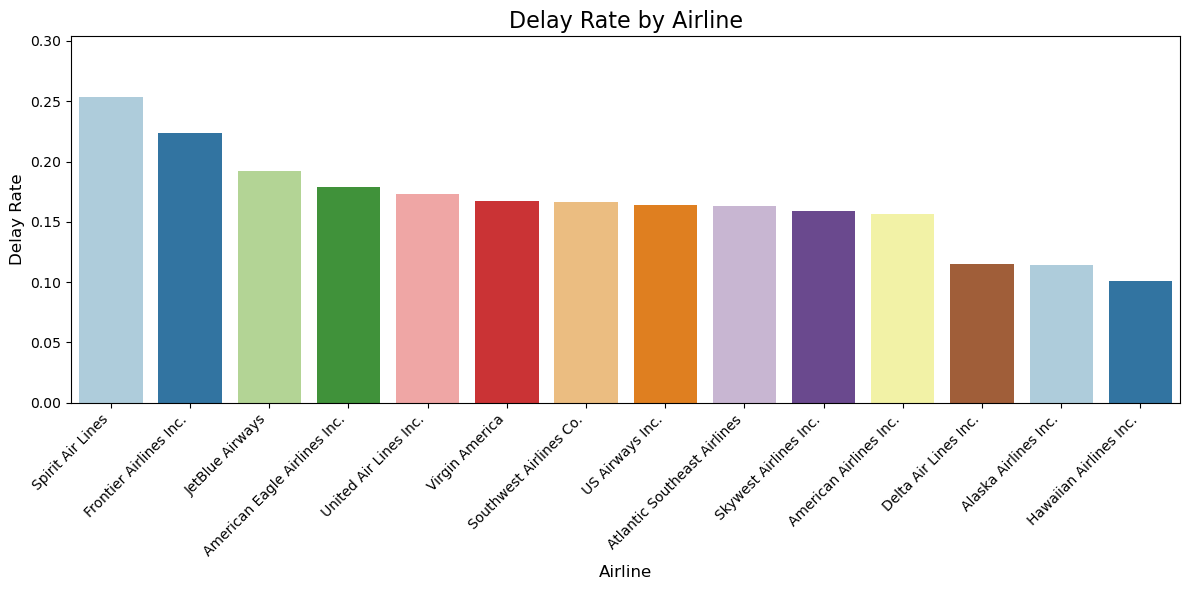

In [108]:
airline_delay = (df_final.groupby("AIRLINE_NAME")["IS_DELAYED"].mean().sort_values(ascending = False).reset_index())

plt.figure(figsize=(12,6)
sns.barplot(data = airline_delay, x = "AIRLINE_NAME", y = "IS_DELAYED", palette = "Paired")
plt.title("Delay Rate by Airline", fontsize=16)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Delay Rate", fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.ylim(0, airline_delay['IS_DELAYED'].max() + 0.05)  
plt.tight_layout()
plt.show()


#### Insight

Airline performance varies significantly, with delay rates ranging from 10% to over 25%. Low-cost carriers such as Spirit and Frontier has the highest delay rates, potentially due to tighter operational constraints. In contrast, airlines like Hawaiian, Alaska, and Delta consistently achieve lower delay rates, indicating more efficient operations. This suggests that airline choice is a significant factor influencing the likelihood of flight delays.

## Delay Time on Airline based on airline delay

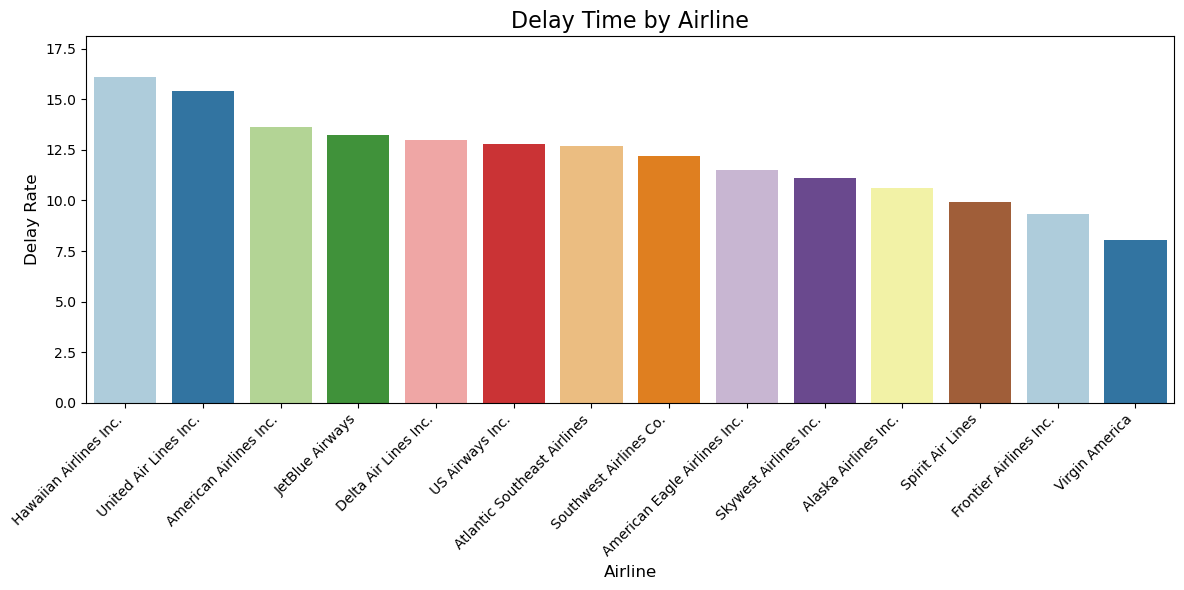

In [115]:
df_airline_delay = df_final.groupby("AIRLINE_NAME")["AIRLINE_DELAY"].mean().sort_values(ascending = False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data = df_airline_delay, x = "AIRLINE_NAME", y = "AIRLINE_DELAY", palette = "Paired")
plt.title("Delay Time by Airline", fontsize=16)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Delay Rate", fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.ylim(0, df_airline_delay['AIRLINE_DELAY'].max() + 2)  
plt.tight_layout()
plt.show()

#### Insight

Airline delay performance differs across two key dimensions: frequency and severity. While low-cost carriers such as Spirit and Frontier experience delays more frequently, their delays tend to be shorter in duration. In contrast, airlines like Hawaiian exhibit fewer delays overall, but when delays occur, they tend to last longer.

## Top Departing Airports with Highest Delay Rate

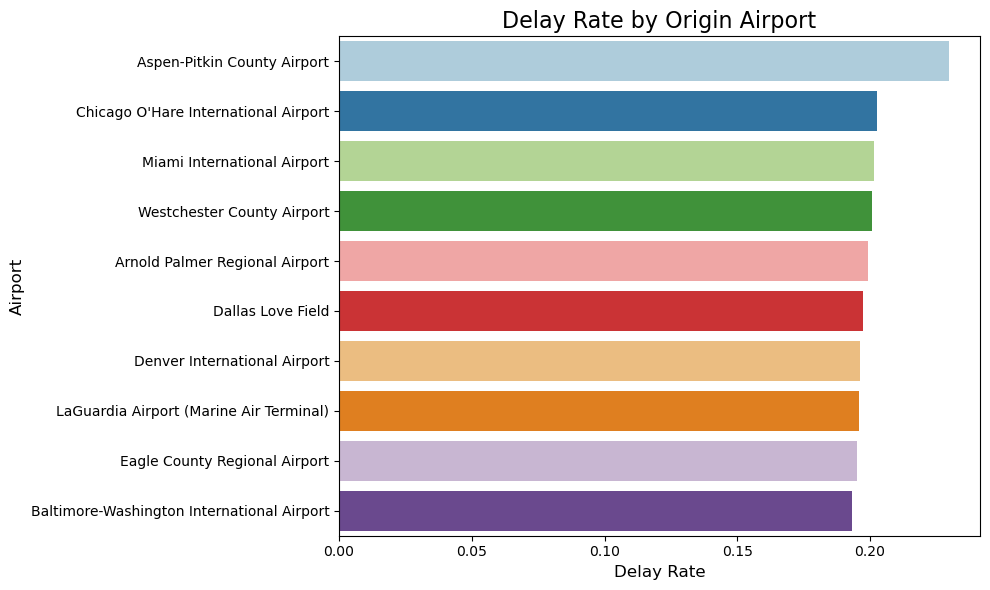

In [118]:
or_delay2 = (depart_delay_airports.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending = False).head(10).reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data = or_delay2, x = "IS_DELAYED", y = "ORIGIN_AIRPORT", palette = "Paired")
plt.title("Delay Rate by Origin Airport", fontsize = 16)
plt.xlabel("Delay Rate", fontsize = 12)
plt.ylabel("Airport", fontsize = 12)
plt.tight_layout()
plt.show()

##### Insight

 There are  smaller regional airports Like Trenton Mercer but we also see main hub airports in the US like Chicago O'Hare and Miami Airport.   This suggests that flight delays for departing airports are influenced by multiple factors: congestion at large airports and operational or geographic constraints at smaller airports. 

## Top Destination Airports with Highest Delay Rate 

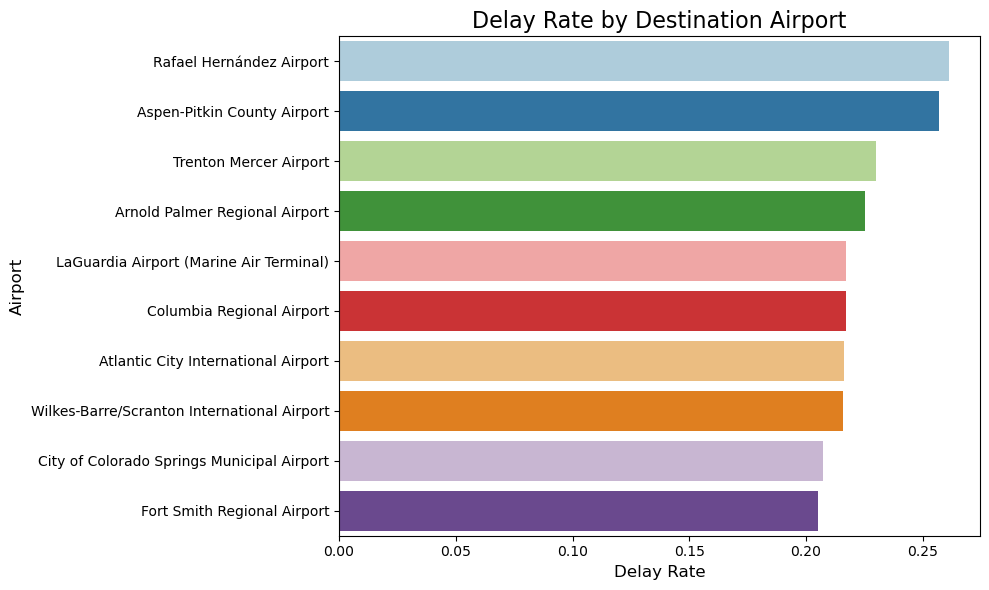

In [119]:
or_dest2 = (dest_delay_airports.groupby("DEST_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending = False).head(10).reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data = or_dest2, x = "IS_DELAYED", y = "DEST_AIRPORT", palette = "Paired")
plt.title("Delay Rate by Destination Airport", fontsize = 16)
plt.xlabel("Delay Rate", fontsize = 12)
plt.ylabel("Airport", fontsize = 12)
plt.tight_layout()
plt.show()

#### Insight

 Unlike departure delays, where major hub airports are more common in the top 10, arrival delays are more prevalent at smaller regional airports. This suggests that destination-specific constraints such as limited runway capacity, geographic challenges, and reduced operational flexibility play a significant role in arrival delays. Smaller airports may struggle to efficiently absorb incoming traffic, leading to higher delay rates.

## Flight Delay Causes

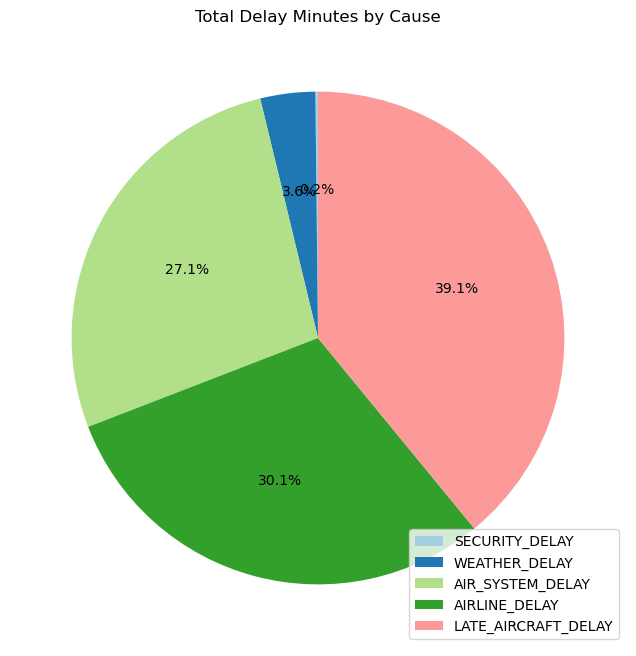

In [120]:
delay_totals = df_final[delay_breakdown_cols].sum().sort_values()

plt.figure(figsize=(8,8))
plt.pie(
    delay_totals,
    labels=None,
    colors=sns.color_palette("Paired"),
    autopct="%1.1f%%",
    startangle=90
)
plt.legend(labels = delay_totals.index, loc = "best")
plt.title("Total Delay Minutes by Cause")
plt.tight_layout()
plt.show()

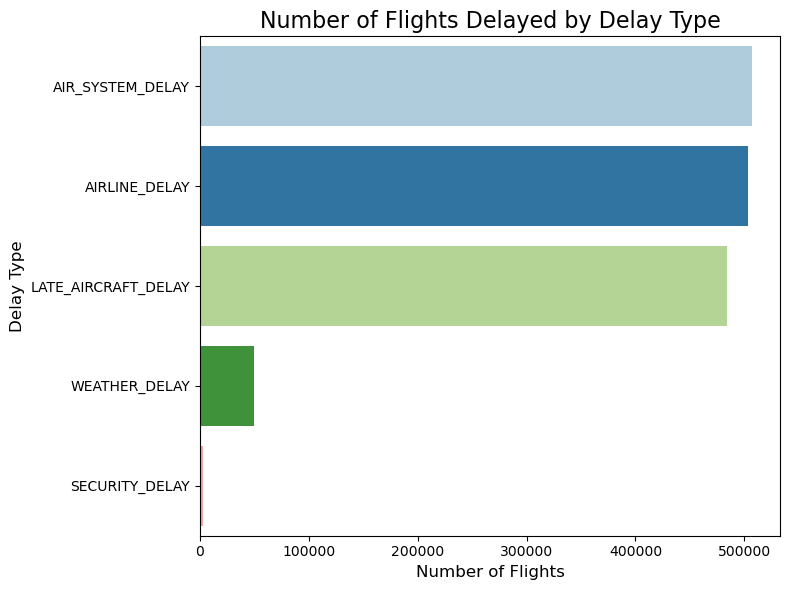

In [125]:
delay_count = (df_final[delay_breakdown_cols] > 0).sum().sort_values(ascending=False)
delay_count = delay_count.reset_index()
delay_count.columns = ["Delay Type", "Count"]

plt.figure(figsize=(8,6))
sns.barplot(data = delay_count, x='Count', y='Delay Type',palette = "Paired")
plt.title("Number of Flights Delayed by Delay Type", fontsize = 16)
plt.xlabel("Number of Flights", fontsize = 12)
plt.ylabel("Delay Type", fontsize = 12)
plt.tight_layout()
plt.show()

#### Insights

With delays the most common is late aircraft delay follow by airline then air system delay, with weather and security making up 5%.  This indicates that most flight delays are cause through the system either from earlier flights or airline operational inefficiencies rather than caused directly by weather or security incidents. Addressing these issues would have the greatest impact on reducing overall flight delays.

# Delay Time Trends

<Figure size 640x480 with 0 Axes>

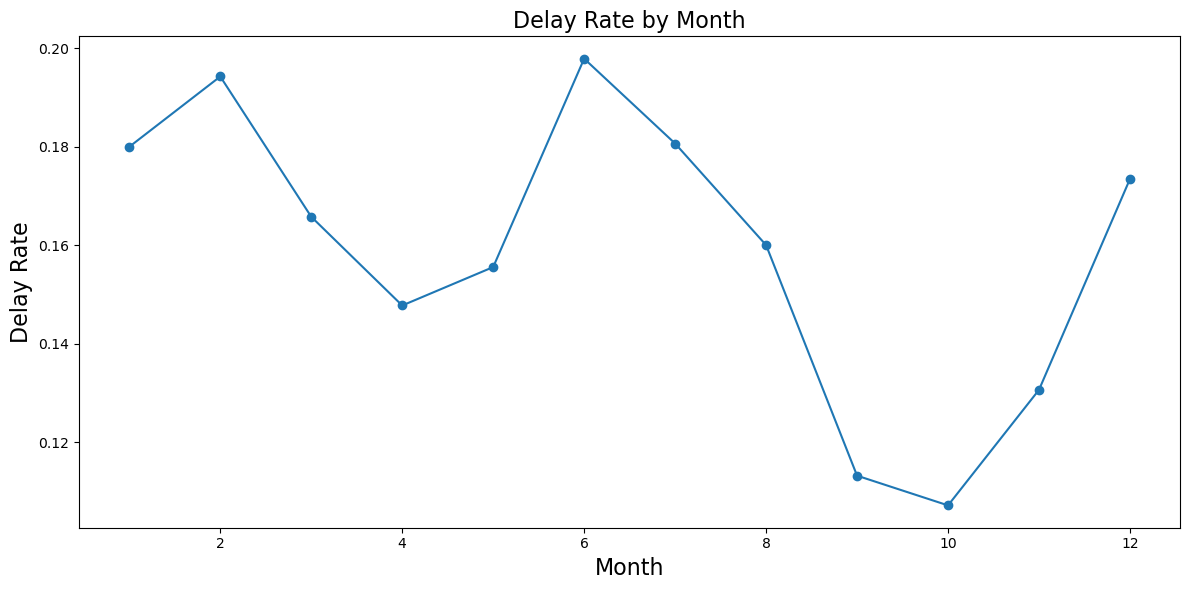

In [127]:
monthly_delay = df_final.groupby("MONTH")["IS_DELAYED"].mean()
plt.figure()
plt.figure(figsize=(12,6))
monthly_delay.plot(marker="o")
plt.title("Delay Rate by Month", fontsize = 16)
plt.xlabel("Month", fontsize = 16)
plt.ylabel("Delay Rate", fontsize = 16)
plt.tight_layout()
plt.show()

#### Insights

Analysis of average monthly delay rates shows clear seasonal patterns. Delays peak in June, February, and July, likely due to a combination of high travel demand during summer vacations and winter weather disruptions in early months. The lowest delays occur in September and October, reflecting off-peak travel periods and more stable weather. This seasonal insight can help airlines and passengers plan better for high-risk months.

### Time Trends split by delays

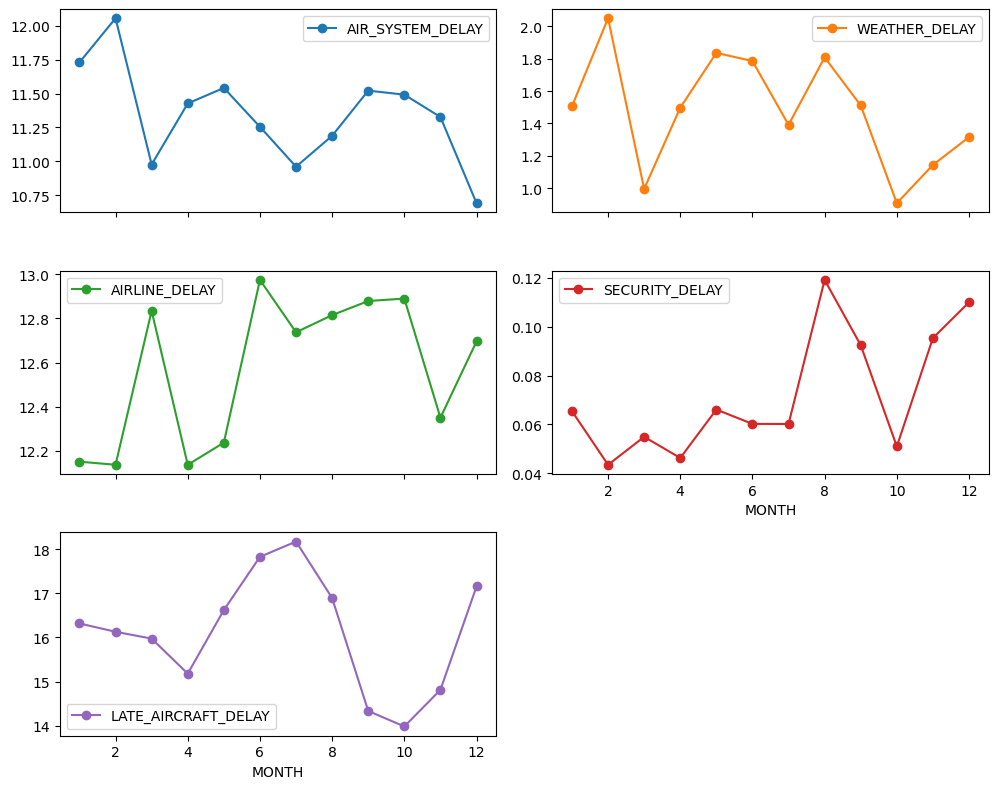

In [59]:
monthly_delay = df_final.groupby("MONTH")[delay_breakdown_cols].mean()

monthly_delay.plot(subplots=True, layout=(3,2), figsize=(10,8), marker="o")
plt.tight_layout()
plt.show()

#### Insights

Monthly delay analysis by cause shows that late aircraft arrivals and airline operational issues are consistently the largest contributors to delays throughout the year, peaking in summer and winter months. Weather-related delays have a minor role overall but spike in February and May, likely due to winter storms and spring weather events. Security delays remain negligible. These patterns indicate that most flight delays are propagated through the system or caused by operational inefficiencies, rather than by airport-specific issues or weather alone. Airlines and airports could reduce overall delays by focusing on improving operational resilience and schedule management, especially during peak travel months.

## Conclusion

This analysis of over 5 million flights reveals several key patterns in U.S. flight delays:

- **Airline delay varies significantly in both frequency and severity.** Low-cost carriers like Spirit (~25%) and Frontier (~22%) had the highest delay rates, while Hawaiian and Alaska Airlines hovered near 10%. However, when delays did occur at Hawaiian, they tended to last longer — meaning delay rate alone does not tell the full story.
- **Late aircraft, air system and airline operational issues are the dominant delay causes**, together accounting for roughly 95% of all delay time in the dataset. Weather and security delays, while disruptive when they occur, are minor contributors overall (~5% combined).
- **Delays follow a strong seasonal pattern**, peaking in June and July (summer travel) and February (winter weather), with the lowest rates in September and October. This pattern holds across most delay types.
- **Arrival delays skew toward smaller regional airports**, while departure delays are more concentrated at major hubs like Chicago O'Hare and LaGuardia — suggesting different root causes (congestion vs. operational constraints) depending on direction of travel.

### Recommendations

- **For Airlines:** Improving in schedule buffer and aircraft turnaround efficiency, particularly during peak summer and winter months. Since late aircraft is the leading delay cause, reducing delay build up through the day's schedule would have the highest system-wide impact.
- **For Travelers:** Flying in September or October minimizes delay risk. When choosing an airline, weigh both delay frequency and typical delay length — a carrier with fewer but longer delays may be more disruptive on tight connections than one with more frequent but shorter delays. Avoid budget carriers on itineraries with minimal connection time.

While some flight delays are random and unavoidable, many happen for reasons that can be managed, like late arrivals, airline operations, or tight schedules. Airlines that plan better and give themselves extra time between flights can help reduce delays.